In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [3]:
train_dataset = MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:22<00:00, 437kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 71.0kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:05<00:00, 277kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.95MB/s]


In [6]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)


In [9]:
train_dataloader.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [10]:
train_dataloader.sampler

In [11]:
X , y = next(iter(train_dataloader))
print(X.shape)
y.shape

torch.Size([64, 1, 28, 28])


torch.Size([64])

image_label : 5


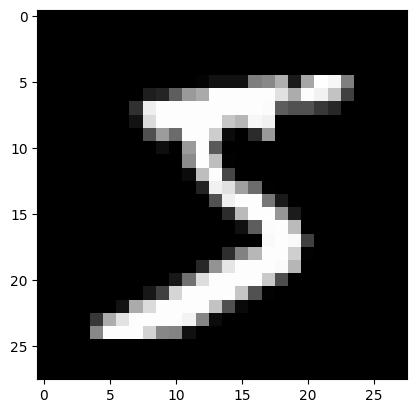

In [17]:
from matplotlib import pyplot as plt 
img = X[0].squeeze()
label = y[0]
plt.imshow(img , cmap= "gray")
print("image_label :",label.item())

In [28]:
# # kernal/ filter 
# k = torch.rand(3,3)* (2/9)**0.5
# k[:,1] = 0 
# k[:,2] *= -1 
# k

tensor([[ 0.2167,  0.0000, -0.3485],
        [ 0.2915,  0.0000, -0.1161],
        [ 0.1237,  0.0000, -0.0598]])

In [50]:
import math 
# Fibonacci-based magnitudes
fib = torch.tensor([1., 1., 2.])
fib = fib / fib.norm()   # normalize for stability

# fan_in = 3 * 3
fan_in = 9
scale = math.sqrt(2 / fan_in)  # He-style scaling

# Initialize kernel
k = torch.zeros(3, 3)

# Left column (positive)
k[:, 0] = fib

# Middle column (zero)
k[:, 1] = 0.0

# Right column (negative)
k[:, 2] = -fib

# Apply variance scaling
k *= scale

k


tensor([[ 0.1925,  0.0000, -0.1925],
        [ 0.1925,  0.0000, -0.1925],
        [ 0.3849,  0.0000, -0.3849]])

In [42]:
(img[7:10,7:10] * k ).sum()

tensor(-0.4353)

In [43]:
# let image size 5x5
torch.rand(5,5)

tensor([[0.1540, 0.2548, 0.9632, 0.5073, 0.4630],
        [0.3104, 0.8886, 0.6835, 0.0126, 0.7614],
        [0.6162, 0.7485, 0.8806, 0.5726, 0.7755],
        [0.1861, 0.4478, 0.9876, 0.6348, 0.2120],
        [0.3705, 0.4051, 0.0500, 0.2870, 0.3514]])

In [44]:
# when we apply filter of 3x3 with stride 1 image size reduced by 2 rows and 2 columns

In [34]:
r , c = img.shape
r,c

(28, 28)

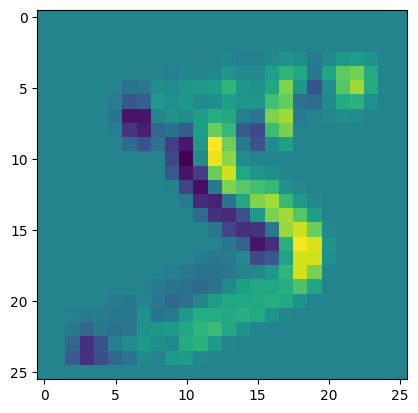

In [48]:
def conv2d_single_channel(image, kernel, stride:int() = 1 ):
    """
    image  : torch.Tensor of shape (H, W) or (1, H, W)
    kernel : torch.Tensor of shape (kH, kW)
    stride : int
    return : torch.Tensor of shape (H_out, W_out)
    """
# H stands for height and W stands for width 
    # ensure image is (H, W)
    if image.dim == 3 :
        image.squeeze(0)

    H , W = image.shape
    kH , kW = kernel.shape
    H_out = (H - kH) // stride + 1 
    W_out = (W - kW) // stride + 1 
    output = torch.zeros((H_out,W_out))

    for h in range(H_out):
        for w in range(W_out):
            h_start = h * stride
            w_start = w * stride
            
            patch = image[h_start:h_start+kH, w_start:w_start+kW]
            output[h,w] = torch.sum(patch * kernel)

    return output    
plt.imshow(conv2d_single_channel(img , k ))

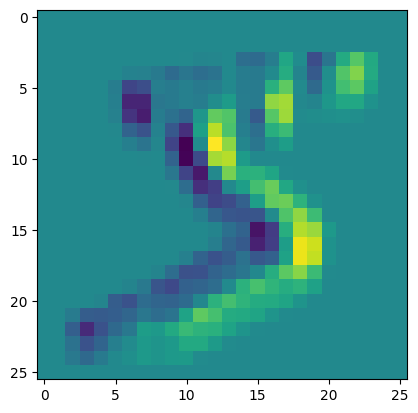

In [51]:
plt.imshow(conv2d_single_channel(img , k ))